## Part 2: Dataset Creation 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Policy_Sales_DATA preparation

In [3]:
n = 1000000

In [4]:
customer_id = np.arange(1, n+1)

In [5]:
vehicle_id = np.arange(1, n+1)

In [6]:
customer_id , vehicle_id

(array([      1,       2,       3, ...,  999998,  999999, 1000000],
       shape=(1000000,)),
 array([      1,       2,       3, ...,  999998,  999999, 1000000],
       shape=(1000000,)))

In [7]:
vehicle_value = 100000

In [8]:
tenure = np.random.choice(
    [1,2,3,4],
    size = n,
    p = [0.2,0.3,0.4,0.1]
)

In [9]:
tenure

array([3, 3, 4, ..., 2, 3, 2], shape=(1000000,))

In [10]:
premium = tenure * 100

In [11]:
premium

array([300, 300, 400, ..., 200, 300, 200], shape=(1000000,))

In [12]:
dates = pd.date_range("2024-01-01","2024-12-31")

In [13]:
dates

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[us]', length=366, freq='D')

In [14]:
purchase_date = np.random.choice(dates, n)

In [15]:
purchase_date

array(['2024-01-20T00:00:00.000000', '2024-06-11T00:00:00.000000',
       '2024-02-11T00:00:00.000000', ..., '2024-07-27T00:00:00.000000',
       '2024-08-15T00:00:00.000000', '2024-12-24T00:00:00.000000'],
      shape=(1000000,), dtype='datetime64[us]')

In [16]:
policy_start = pd.to_datetime(purchase_date) + pd.Timedelta(days=365)

In [17]:
policy_start

DatetimeIndex(['2025-01-19', '2025-06-11', '2025-02-10', '2025-03-13',
               '2025-02-03', '2025-12-11', '2025-09-01', '2025-07-15',
               '2025-03-03', '2025-04-19',
               ...
               '2025-12-29', '2025-07-28', '2025-06-08', '2025-12-20',
               '2025-03-10', '2025-10-11', '2025-07-16', '2025-07-27',
               '2025-08-15', '2025-12-24'],
              dtype='datetime64[us]', length=1000000, freq=None)

In [18]:
policy_end = policy_start + pd.to_timedelta(tenure*365, unit='D')

In [19]:
policy_end

DatetimeIndex(['2028-01-19', '2028-06-10', '2029-02-09', '2028-03-12',
               '2028-02-03', '2028-12-10', '2026-09-01', '2028-07-14',
               '2029-03-02', '2027-04-19',
               ...
               '2026-12-29', '2028-07-27', '2026-06-08', '2027-12-20',
               '2026-03-10', '2028-10-10', '2027-07-16', '2027-07-27',
               '2028-08-14', '2027-12-24'],
              dtype='datetime64[us]', length=1000000, freq=None)

In [20]:
policy_df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Vehicle_ID": vehicle_id,
    "Vehicle_Value": vehicle_value,
    "Premium": premium,
    "Policy_Purchase_Date": purchase_date,
    "Policy_Start_Date": policy_start,
    "Policy_End_Date": policy_end,
    "Policy_Tenure": tenure
})

In [21]:
policy_df

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,1,1,100000,300,2024-01-20,2025-01-19,2028-01-19,3
1,2,2,100000,300,2024-06-11,2025-06-11,2028-06-10,3
2,3,3,100000,400,2024-02-11,2025-02-10,2029-02-09,4
3,4,4,100000,300,2024-03-13,2025-03-13,2028-03-12,3
4,5,5,100000,300,2024-02-04,2025-02-03,2028-02-03,3
...,...,...,...,...,...,...,...,...
999995,999996,999996,100000,300,2024-10-11,2025-10-11,2028-10-10,3
999996,999997,999997,100000,200,2024-07-16,2025-07-16,2027-07-16,2
999997,999998,999998,100000,200,2024-07-27,2025-07-27,2027-07-27,2
999998,999999,999999,100000,300,2024-08-15,2025-08-15,2028-08-14,3


In [22]:
policy_df.to_csv("policy_sales_data.csv",index=False)

In [23]:
#Claims_DATA preparation

In [24]:
eligible_days = [7,14,21,28]

In [25]:
policy_df["purchase_day"] = policy_df["Policy_Purchase_Date"].dt.day

In [26]:
policy_df

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
0,1,1,100000,300,2024-01-20,2025-01-19,2028-01-19,3,20
1,2,2,100000,300,2024-06-11,2025-06-11,2028-06-10,3,11
2,3,3,100000,400,2024-02-11,2025-02-10,2029-02-09,4,11
3,4,4,100000,300,2024-03-13,2025-03-13,2028-03-12,3,13
4,5,5,100000,300,2024-02-04,2025-02-03,2028-02-03,3,4
...,...,...,...,...,...,...,...,...,...
999995,999996,999996,100000,300,2024-10-11,2025-10-11,2028-10-10,3,11
999996,999997,999997,100000,200,2024-07-16,2025-07-16,2027-07-16,2,16
999997,999998,999998,100000,200,2024-07-27,2025-07-27,2027-07-27,2,27
999998,999999,999999,100000,300,2024-08-15,2025-08-15,2028-08-14,3,15


In [27]:
eligible = policy_df[policy_df["purchase_day"].isin(eligible_days)]

In [28]:
eligible

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
11,12,12,100000,100,2024-12-07,2025-12-07,2026-12-07,1,7
29,30,30,100000,200,2024-09-14,2025-09-14,2027-09-14,2,14
30,31,31,100000,300,2024-01-21,2025-01-20,2028-01-20,3,21
34,35,35,100000,300,2024-07-28,2025-07-28,2028-07-27,3,28
39,40,40,100000,300,2024-08-21,2025-08-21,2028-08-20,3,21
...,...,...,...,...,...,...,...,...,...
999977,999978,999978,100000,300,2024-06-14,2025-06-14,2028-06-13,3,14
999986,999987,999987,100000,200,2024-05-07,2025-05-07,2027-05-07,2,7
999988,999989,999989,100000,200,2024-05-07,2025-05-07,2027-05-07,2,7
999989,999990,999990,100000,200,2024-11-07,2025-11-07,2027-11-07,2,7


In [29]:
eligible.shape

(131813, 9)

In [30]:
claims_2025 = eligible.sample(frac=0.30, random_state=42)

In [31]:
claims_2025

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
376283,376284,376284,100000,200,2024-09-21,2025-09-21,2027-09-21,2,21
657543,657544,657544,100000,200,2024-04-07,2025-04-07,2027-04-07,2,7
65218,65219,65219,100000,200,2024-01-28,2025-01-27,2027-01-27,2,28
288964,288965,288965,100000,300,2024-03-28,2025-03-28,2028-03-27,3,28
498866,498867,498867,100000,200,2024-03-21,2025-03-21,2027-03-21,2,21
...,...,...,...,...,...,...,...,...,...
237535,237536,237536,100000,300,2024-04-21,2025-04-21,2028-04-20,3,21
96328,96329,96329,100000,200,2024-11-14,2025-11-14,2027-11-14,2,14
399621,399622,399622,100000,300,2024-02-28,2025-02-27,2028-02-27,3,28
142454,142455,142455,100000,300,2024-04-21,2025-04-21,2028-04-20,3,21


In [32]:
claims_df = pd.DataFrame({
    "Claim_ID": np.arange(1, len(claims_2025)+1),
    "Customer_ID": claims_2025["Customer_ID"],
    "Vehicle_ID": claims_2025["Vehicle_ID"],
    "Claim_Amount": 10000,
    "Claim_Date": claims_2025["Policy_Start_Date"],
    "Claim_Type": 1
})

In [33]:
claims_df

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
376283,1,376284,376284,10000,2025-09-21,1
657543,2,657544,657544,10000,2025-04-07,1
65218,3,65219,65219,10000,2025-01-27,1
288964,4,288965,288965,10000,2025-03-28,1
498866,5,498867,498867,10000,2025-03-21,1
...,...,...,...,...,...,...
237535,39540,237536,237536,10000,2025-04-21,1
96328,39541,96329,96329,10000,2025-11-14,1
399621,39542,399622,399622,10000,2025-02-27,1
142454,39543,142455,142455,10000,2025-04-21,1


In [34]:
claims_df.to_csv("claims_data.csv",index=False)

## Part4 : Bonus Questions

In [35]:
#1 Identify which policy tenure appears most profitable and explain why. 
merged = policy_df.merge(claims_df, on=["Customer_ID","Vehicle_ID"], how="left")

analysis = merged.groupby("Policy_Tenure").agg({
    "Premium":"sum",
    "Claim_Amount":"sum"
}).fillna(0)

analysis["Profit"] = analysis["Premium"] - analysis["Claim_Amount"]

In [36]:
analysis

,Premium,Claim_Amount,Profit
Policy_Tenure,,,
1,20087300,79570000.0,-59482700.0
2,59975200,118100000.0,-58124800.0
3,119771100,158300000.0,-38528900.0
4,40005600,39470000.0,535600.0


#### The 4-year policy tenure appears to be the most profitable because the total premium collected from these policies is slightly higher than the claims paid. In contrast, other tenures show significantly higher claim costs compared to the premium collected, resulting in negative profitability

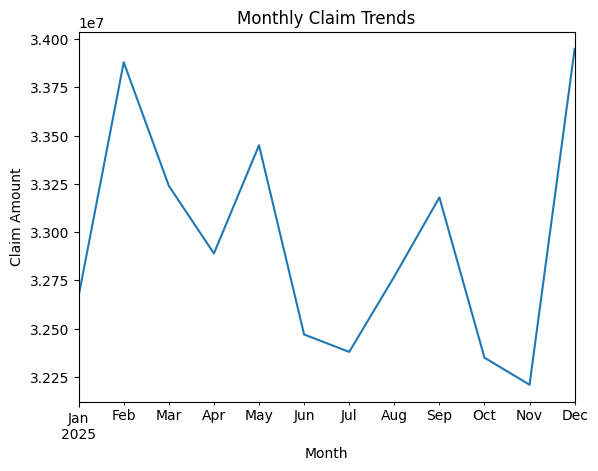

In [37]:
#2. Build a simple dashboard or visualization showing claim trends by month.
claims_df["Month"] = claims_df["Claim_Date"].dt.to_period("M")

monthly_claims = claims_df.groupby("Month")["Claim_Amount"].sum()

monthly_claims.plot(kind="line")

plt.title("Monthly Claim Trends")
plt.xlabel("Month")
plt.ylabel("Claim Amount")
plt.show()

In [38]:
#3  Estimate the loss ratio (Claims ÷ Premium) for the portfolio.
total_claims = claims_df["Claim_Amount"].sum()
total_premium = policy_df["Premium"].sum()

loss_ratio = total_claims / total_premium

In [39]:
loss_ratio

np.float64(1.6487713434667894)

In [40]:
#4 If claim frequency increases by 5% annually, estimate the impact on future profitability. 
future_claims = total_claims * 1.05
future_loss_ratio = future_claims / total_premium


In [41]:
future_loss_ratio

np.float64(1.7312099106401289)